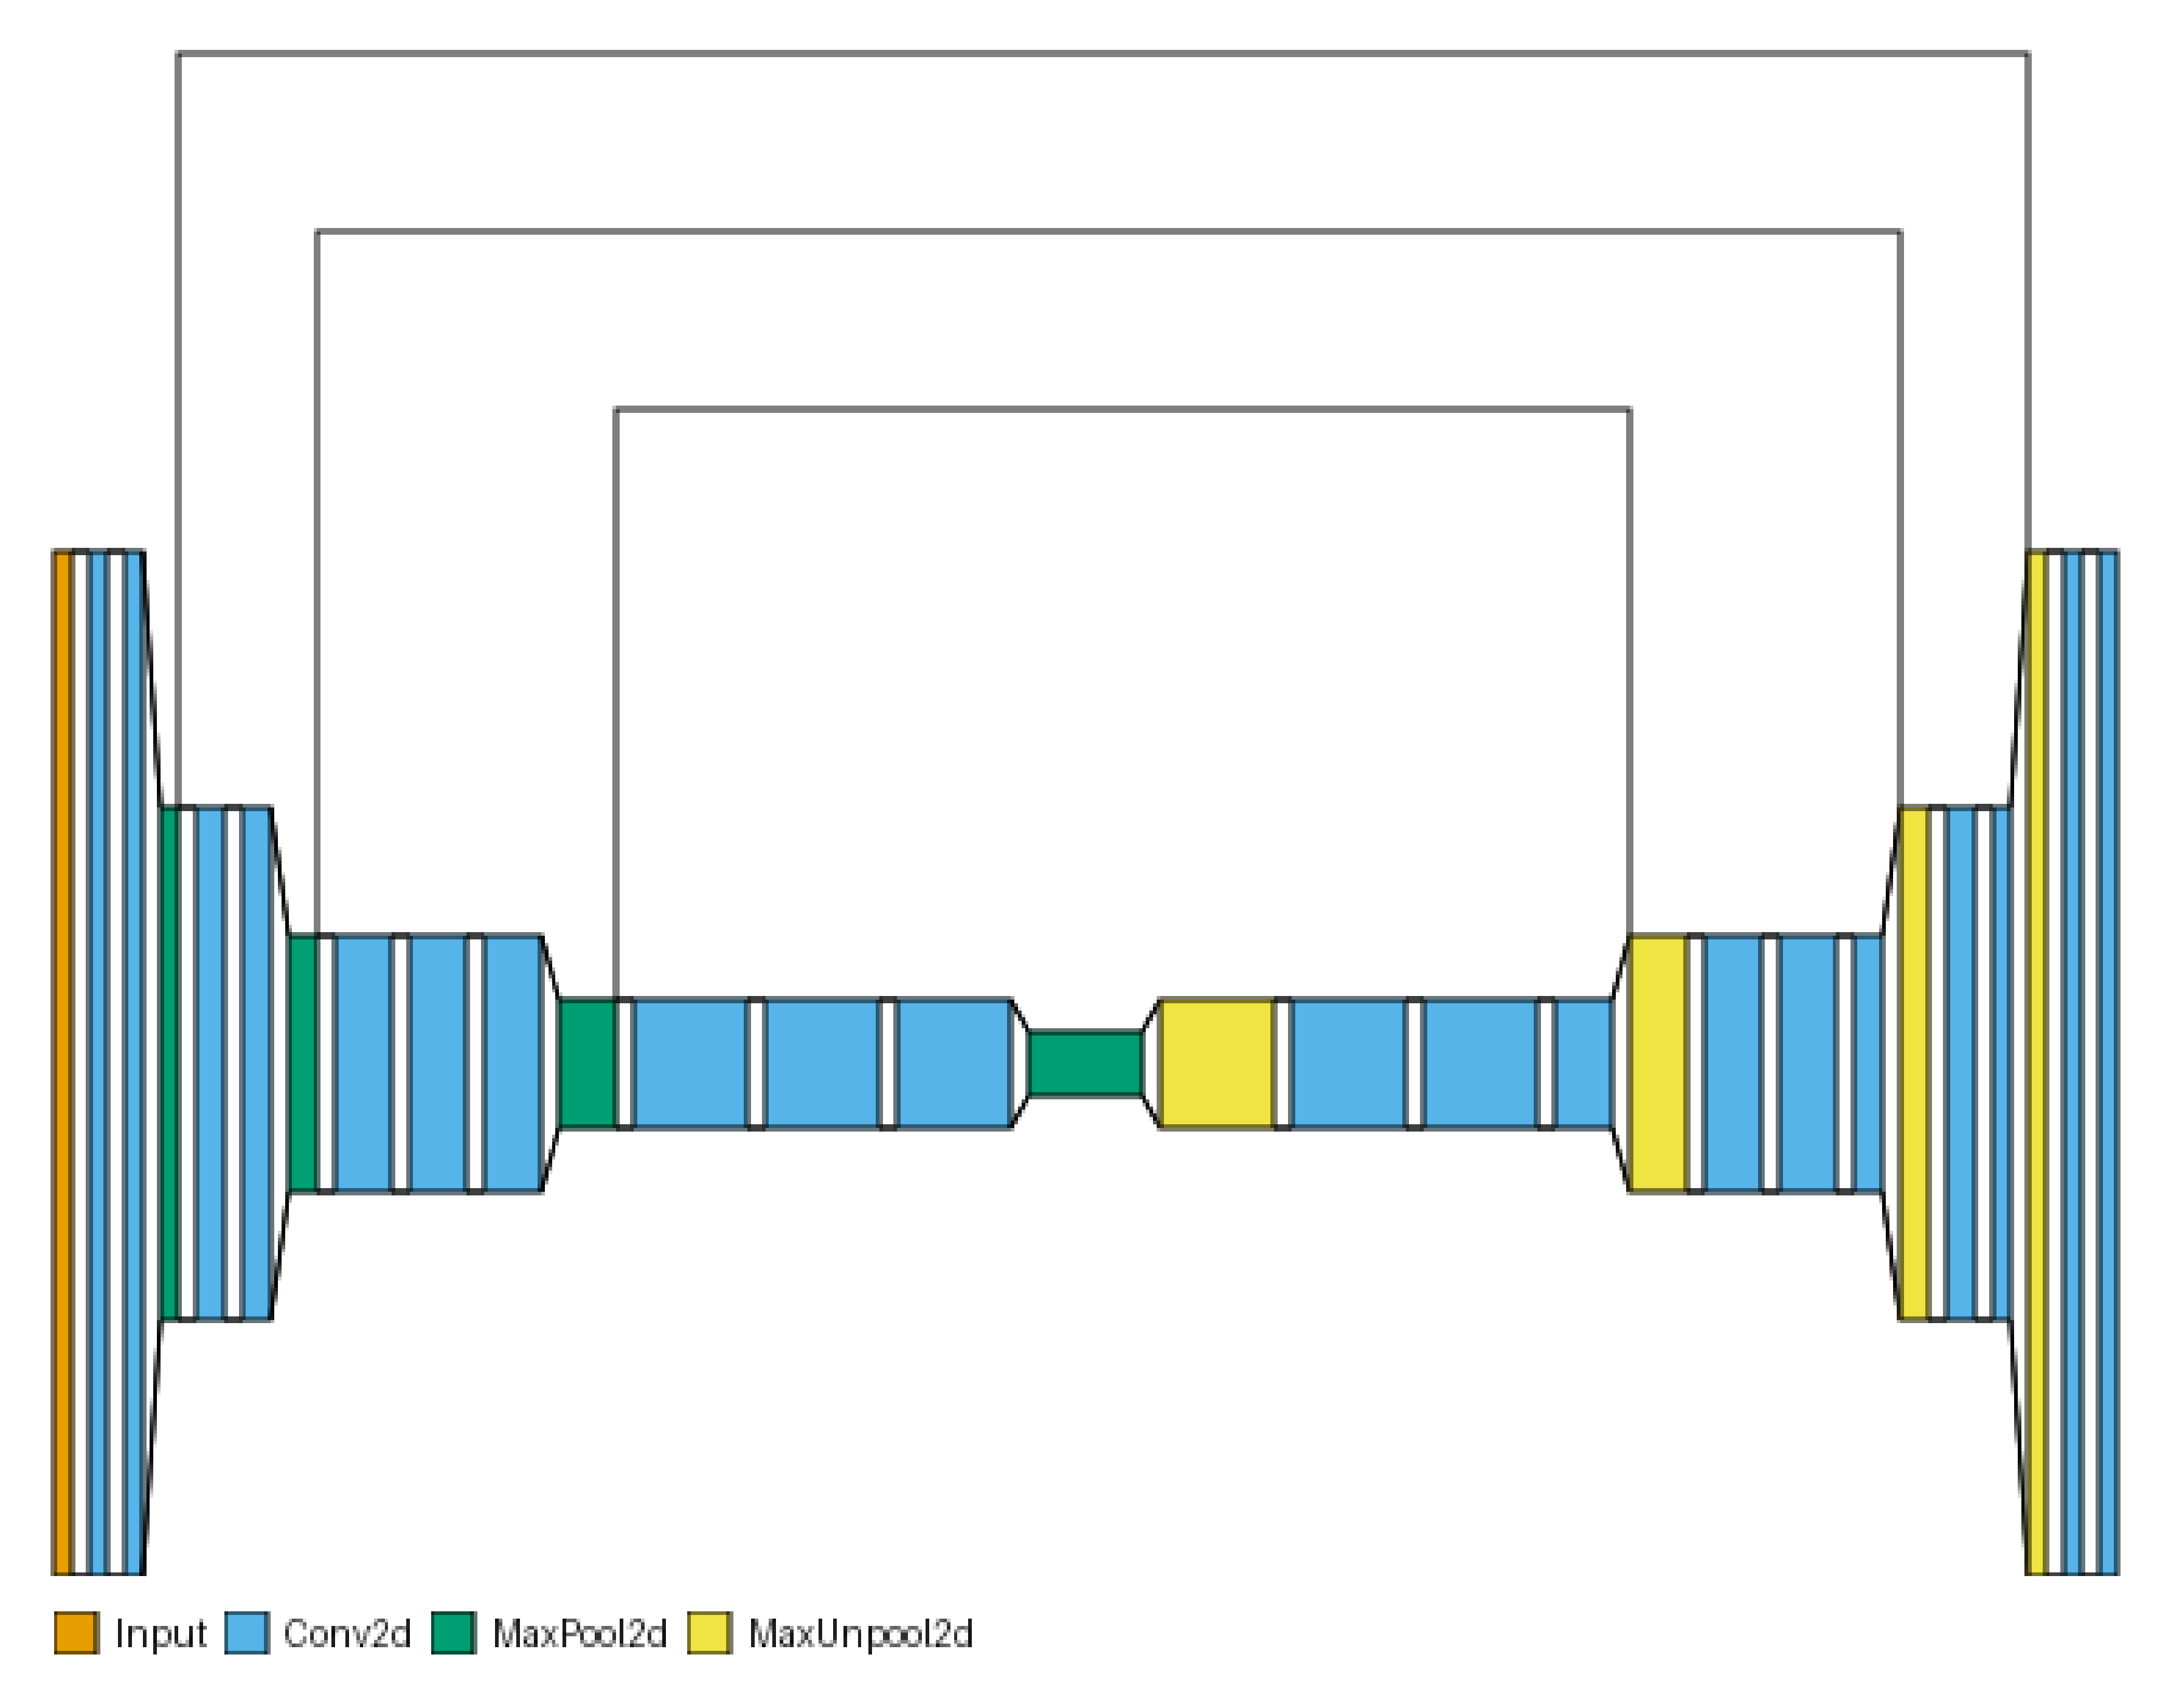

In [1]:
import cygnet
import matplotlib.pyplot as plt
import visualtorch, torch
from torch import nn

class DoubleDown2(nn.Module):
	def __init__(self, chin, chout):
		super().__init__()
		self.seq = nn.Sequential(
			nn.Conv2d(chin, chout, 3, padding=1, bias=False),
			nn.Conv2d(chout, chout, 3, padding=1, bias=False),
		)
		self.mp = nn.MaxPool2d(2, return_indices=True)

	def forward(self, x):
		y = self.seq(x)
		pool_shape = y.shape
		y, indices = self.mp(y)
		return y, indices, pool_shape

class DoubleDown3(nn.Module):
	def __init__(self, chin, chout):
		super().__init__()
		self.seq = nn.Sequential(
			nn.Conv2d(chin, chout, 3, padding=1, bias=False),
			nn.Conv2d(chout, chout, 3, padding=1, bias=False),
			nn.Conv2d(chout, chout, 3, padding=1, bias=False),
		)
		self.mp = nn.MaxPool2d(2, return_indices=True)

	def forward(self, x):
		y = self.seq(x)
		pool_shape = y.shape
		y, indices = self.mp(y)
		return y, indices, pool_shape

class DoubleUp2(nn.Module):
	def __init__(self, chin, chout):
		super().__init__()
		self.seq = nn.Sequential(
			nn.Conv2d(chin, chin, 3, padding=1, bias=False),
			nn.Conv2d(chin, chout, 3, padding=1, bias=False),
		)
		self.mup = nn.MaxUnpool2d(2)
		
	def forward(self, x, indices, output_size):
		y = self.mup(x, indices, output_size=output_size)
		y = self.seq(y)
		return y

class DoubleUp3(nn.Module):
	def __init__(self, chin, chout):
		super().__init__()
		self.seq = nn.Sequential(
			nn.Conv2d(chin, chin, 3, padding=1, bias=False),
			nn.Conv2d(chin, chin, 3, padding=1, bias=False),
			nn.Conv2d(chin, chout, 3, padding=1, bias=False),
		)
		self.mup = nn.MaxUnpool2d(2)
		
	def forward(self, x, indices, output_size):
		y = self.mup(x, indices, output_size=output_size)
		y = self.seq(y)
		return y

class DoubleUp2Out(nn.Module):
	def __init__(self, chin, chout):
		super().__init__()
		self.seq = nn.Sequential(
			nn.Conv2d(chin, chin, 3, padding=1, bias=False),
			nn.Conv2d(chin, chout, 3, padding=1, bias=False),
		)
		self.mup = nn.MaxUnpool2d(2)
		
	def forward(self, x, indices, output_size):
		y = self.mup(x, indices, output_size=output_size)
		y = self.seq(y)
		return y

class SkipNet(nn.Module):
	def __init__(self, base):
		super().__init__()
		self.bn_input = nn.BatchNorm2d(1)
		
		self.dc1 = DoubleDown2(1, base)
		self.dc2 = DoubleDown2(base, base*2)
		self.dc3 = DoubleDown3(base*2, base*4)
		self.dc4 = DoubleDown3(base*4, base*8)
		self.dc5 = DoubleDown3(base*8, base*8)
		
		self.uc5 = DoubleUp3(base*8, base*8)
		self.uc4 = DoubleUp3(base*8, base*4)
		self.uc3 = DoubleUp3(base*4, base*2)
		self.uc2 = DoubleUp2(base*2, base)
		self.uc1 = DoubleUp2Out(base, 1)

	def forward(self, batch: torch.Tensor):
		x = batch#self.bn_input(batch)

		x1, mp1_indices, shape1 = self.dc1(x)
		x2, mp2_indices, shape2 = self.dc2(x1)
		x3, mp3_indices, shape3 = self.dc3(x2)
		x4, mp4_indices, shape4 = self.dc4(x3)
		#x, mp5_indices, shape5 = self.dc5(x)

		#x = self.uc5(x, mp5_indices, output_size=shape5)
		x = self.uc4(x4, mp4_indices, output_size=shape4)
		x = self.uc3(x3 + x, mp3_indices, output_size=shape3)
		x = self.uc2(x + x2, mp2_indices, output_size=shape2)
		x = self.uc1(x + x1, mp1_indices, output_size=shape1)
		
		return x

input_shape = (1, 1, 1024, 576)
model = SkipNet(16)

ignored_layers = [nn.ReLU, nn.Dropout, nn.BatchNorm2d]
pathf = cygnet.figures_path + "arch.pdf"

img = visualtorch.render(model, 
						 input_shape=input_shape, 
						 style="flow", 
						 legend=True,
						 spacing=5,
						 draw_funnel=True,
						 show_dimension=False,
						 show_input=True,
						 draw_volume=False,
						 shade_step=50,
						 scale_xy=0.5,
						 scale_z=1/4,
						 min_z=5,
						 type_ignore=ignored_layers,
						 level_gap= None
						 )

dpi = 300  # rendered at 2x this in the final doc build (savefig.dpi=300 in conf.py)
# plt.figure(figsize=(img.width / dpi, img.height / dpi), dpi=dpi)
plt.figure(figsize=(12, 12), dpi=dpi)
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.savefig(pathf)
plt.show()